# 03 — NLP Preprocessing

**Threat Incident Intelligence Platform**

This notebook prepares textual features for downstream ML and semantic search.

Coverage:
- Text cleaning & tokenization (shared `src.preprocessing`)
- Vocabulary / token statistics
- TF-IDF vectorization (baseline features for classical ML)
- Persist vectorizer artifact for notebooks + Streamlit
- Entity-group feature summary
- Optional keyword co-occurrence peek


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")

Project root: c:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai


In [2]:
from collections import Counter
from typing import Any, Dict, List, Optional

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from src.config import settings, validate_config
from src.db import ping_database, close_connection, count_incidents, find_incidents
from src.preprocessing import (
    clean_text,
    tokenize_and_clean,
    build_tfidf_corpus,
    get_stopwords,
    flatten_entities,
    extract_entity_list,
)
from src.models.loaders import get_models_dir
from src.utils import setup_logging, timer, truncate_text

logger = setup_logging("INFO", name="nlp")
validate_config()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

MODELS_DIR = get_models_dir()
print(f"Models directory: {MODELS_DIR}")
print("Setup complete")

[config] MongoDB URI loaded (db=threat_intelligence)
[config] Collections: ['incidents', 'incident_features', 'predictions', 'models_metadata']
Models directory: C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models
Setup complete


In [3]:
if not ping_database():
    raise RuntimeError("Cannot reach MongoDB. Check .env and ensure the server is running.")

total = count_incidents()
print(f"Total incidents: {total:,}")
if total == 0:
    raise RuntimeError("No documents found. Run 01_data_ingestion.ipynb first.")

Total incidents: 19,204


In [4]:
with timer("Loading incidents"):
    docs = find_incidents(
        projection={
            "_id": 0,
            "cluster_id": 1,
            "title": 1,
            "summary": 1,
            "title_clean": 1,
            "summary_clean": 1,
            "keywords": 1,
            "entities": 1,
            "urgency_level": 1,
            "threat_score": 1,
            "severity_score": 1,
        }
    )

df = pd.DataFrame(docs)
print(f"Shape: {df.shape}")
df.head(2)

[timer] Loading incidents: 0.65s
Shape: (19204, 10)


,cluster_id,title,title_clean,summary,summary_clean,entities,keywords,threat_score,severity_score,urgency_level
0,971184ec,MikroTik RouterOS Vulnerabilities Under Active...,mikrotik routeros vulnerabilities under active...,CERT Polska has identified six critical vulner...,cert polska has identified six critical vulner...,"{'cve': ['CVE-2026-67276', 'CVE-2026-67277', '...","[mikrotik, routeros, vulnerability, vulnerabil...",78.65,85.0,medium
1,ec7534a8,Cyber Security Roles Address NHS Threats Amid ...,cyber security roles address nhs threats amid ...,Two cybersecurity roles have been announced to...,two cybersecurity roles have been announced to...,"{'company': ['NHS'], 'country': ['United Kingd...","[security, cyber, analyst, remote, consultant,...",39.00,40.0,medium


In [5]:
def combine_text(row: pd.Series) -> str:
    """Prefer pre-cleaned fields; fall back to raw + clean_text."""
    title = row.get("title_clean") or clean_text(str(row.get("title") or ""))
    summary = row.get("summary_clean") or clean_text(str(row.get("summary") or ""))
    keywords = row.get("keywords") or []
    kw_str = " ".join(str(k) for k in keywords if k)
    parts = [p for p in [title, summary, kw_str] if p]
    return " ".join(parts)

with timer("Building combined text"):
    df["text_combined"] = df.apply(combine_text, axis=1)

print(f"Empty combined texts: {(df['text_combined'].str.len() == 0).sum()}")
df[["cluster_id", "text_combined"]].head(3)

[timer] Building combined text: 0.51s
Empty combined texts: 0


,cluster_id,text_combined
0,971184ec,mikrotik routeros vulnerabilities under active...
1,ec7534a8,cyber security roles address nhs threats amid ...
2,95d7c722,jetbrains cadence breach: exploitation of unpa...


In [6]:
with timer("Tokenizing corpus"):
    token_lists = [tokenize_and_clean(t, remove_stopwords=True) for t in df["text_combined"]]

df["token_count"] = [len(toks) for toks in token_lists]
all_tokens = [t for toks in token_lists for t in toks]
vocab = Counter(all_tokens)

print(f"Total tokens (with stopword removal): {len(all_tokens):,}")
print(f"Vocabulary size                     : {len(vocab):,}")
print(f"Avg tokens / document               : {df['token_count'].mean():.1f}")
print(f"Median tokens / document            : {df['token_count'].median():.0f}")
print(f"\nTop 20 tokens:")
for tok, cnt in vocab.most_common(20):
    print(f"  {tok:25s} {cnt:,}")

[timer] Tokenizing corpus: 5.79s
Total tokens (with stopword removal): 1,474,216
Vocabulary size                     : 52,047
Avg tokens / document               : 76.8
Median tokens / document            : 85

Top 20 tokens:
  security                  19,053
  data                      10,267
  vulnerabilities           10,150
  cyber                     8,541
  2026                      8,510
  vulnerability             8,193
  ai                        7,468
  cybersecurity             7,346
  users                     7,321
  critical                  6,643
  systems                   5,808
  significant               5,708
  attack                    4,906
  attacks                   4,898
  including                 4,765
  threats                   4,543
  access                    4,477
  breach                    4,313
  risks                     4,290
  malware                   4,270


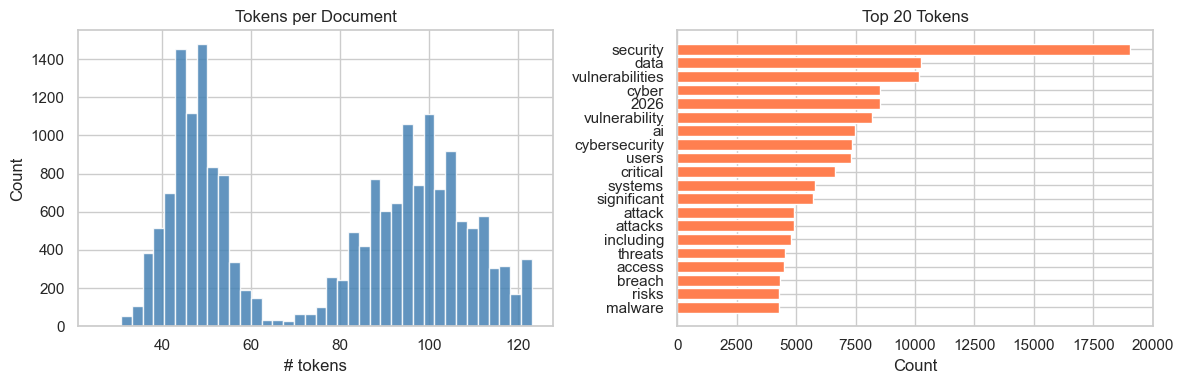

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["token_count"].clip(upper=df["token_count"].quantile(0.99)),
             bins=40, edgecolor="white", alpha=0.85, color="steelblue")
axes[0].set_title("Tokens per Document")
axes[0].set_xlabel("# tokens")
axes[0].set_ylabel("Count")

top20 = vocab.most_common(20)
axes[1].barh([t for t, _ in top20][::-1], [c for _, c in top20][::-1], color="coral")
axes[1].set_title("Top 20 Tokens")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

In [8]:
with timer("Building TF-IDF corpus"):
    corpus = build_tfidf_corpus(df["text_combined"].tolist(), remove_stopwords=True)

print(f"Corpus size: {len(corpus)}")
print(f"Sample: {truncate_text(corpus[0], 120)}")

[timer] Building TF-IDF corpus: 4.11s
Corpus size: 19204
Sample: mikrotik routeros vulnerabilities active exploitation cert polska identified six critical vulnerabilities mikrotik rout…


In [9]:
TFIDF_MAX_FEATURES = 10_000
TFIDF_NGRAM_RANGE = (1, 2)
TFIDF_MIN_DF = 3
TFIDF_MAX_DF = 0.90

vectorizer = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    min_df=TFIDF_MIN_DF,
    max_df=TFIDF_MAX_DF,
    sublinear_tf=True,
    norm="l2",
)

with timer("Fitting TF-IDF"):
    X_tfidf = vectorizer.fit_transform(corpus)

print(f"TF-IDF matrix shape : {X_tfidf.shape}")
print(f"Vocabulary size     : {len(vectorizer.vocabulary_):,}")
print(f"Sparsity            : {1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]):.4f}")

[timer] Fitting TF-IDF: 10.90s
TF-IDF matrix shape : (19204, 10000)
Vocabulary size     : 10,000
Sparsity            : 0.9932


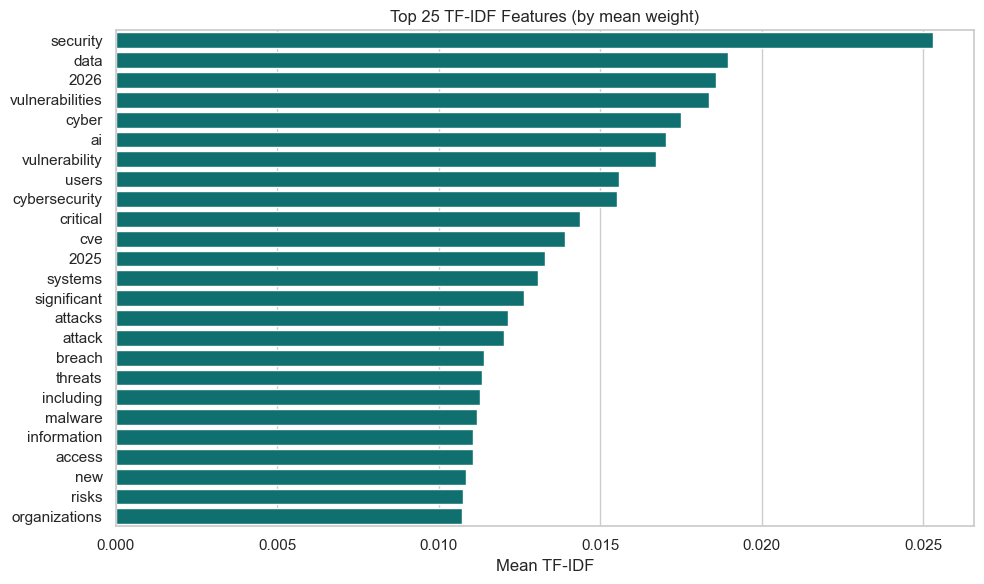

        feature  avg_tfidf
       security   0.025306
           data   0.018951
           2026   0.018578
vulnerabilities   0.018352
          cyber   0.017492
             ai   0.017049
  vulnerability   0.016712
          users   0.015580
  cybersecurity   0.015520
       critical   0.014362


In [10]:
feature_names = np.array(vectorizer.get_feature_names_out())
avg_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
top_idx = avg_tfidf.argsort()[::-1][:25]

top_features_df = pd.DataFrame({
    "feature": feature_names[top_idx],
    "avg_tfidf": avg_tfidf[top_idx],
})

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_features_df, y="feature", x="avg_tfidf", ax=ax, color="teal")
ax.set_title("Top 25 TF-IDF Features (by mean weight)")
ax.set_xlabel("Mean TF-IDF")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print(top_features_df.head(10).to_string(index=False))

In [11]:
vectorizer_path = MODELS_DIR / "tfidf_vectorizer.joblib"
joblib.dump(vectorizer, vectorizer_path)
print(f"Saved TF-IDF vectorizer → {vectorizer_path}")

ids_path = MODELS_DIR / "tfidf_cluster_ids.npy"
matrix_path = MODELS_DIR / "tfidf_matrix.npz"

np.save(ids_path, df["cluster_id"].values)
from scipy import sparse
sparse.save_npz(matrix_path, X_tfidf)

print(f"Saved cluster_ids     → {ids_path}")
print(f"Saved TF-IDF matrix   → {matrix_path}")
print(f"\nArtifacts in models/: {[p.name for p in MODELS_DIR.iterdir()]}")

Saved TF-IDF vectorizer → C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models\tfidf_vectorizer.joblib
Saved cluster_ids     → C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models\tfidf_cluster_ids.npy
Saved TF-IDF matrix   → C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models\tfidf_matrix.npz

Artifacts in models/: ['tfidf_cluster_ids.npy', 'tfidf_matrix.npz', 'tfidf_vectorizer.joblib']


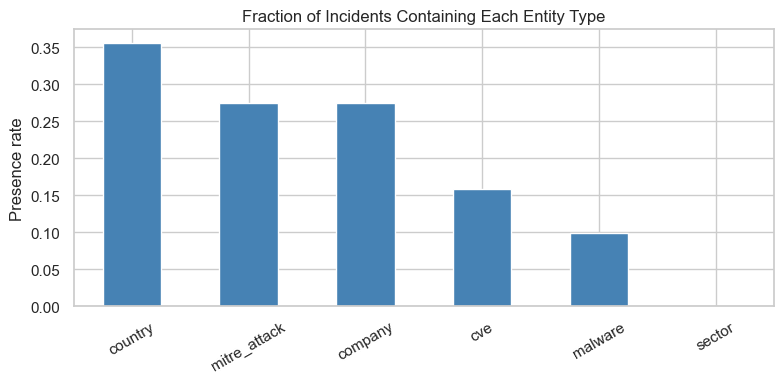

country         0.356
mitre_attack    0.275
company         0.274
cve             0.158
malware         0.099
sector          0.000


In [12]:
ENTITY_TYPES = ["cve", "company", "malware", "country", "sector", "mitre_attack"]

entity_presence = {etype: [] for etype in ENTITY_TYPES}

for _, row in df.iterrows():
    entities = row.get("entities") or {}
    for etype in ENTITY_TYPES:
        vals = entities.get(etype) if isinstance(entities, dict) else None
        entity_presence[etype].append(1 if vals else 0)

presence_df = pd.DataFrame(entity_presence)
presence_rates = presence_df.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
presence_rates.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Fraction of Incidents Containing Each Entity Type")
ax.set_ylabel("Presence rate")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print(presence_rates.round(3).to_string())

In [13]:
def entity_text(row: pd.Series) -> str:
    entities = row.get("entities") or {}
    if not isinstance(entities, dict):
        return ""
    return " ".join(flatten_entities(entities))

df["entity_text"] = df.apply(entity_text, axis=1)
print(f"Docs with non-empty entity_text: {(df['entity_text'].str.len() > 0).sum():,}")
print(f"Sample: {truncate_text(df['entity_text'].iloc[0], 100)}")

Docs with non-empty entity_text: 16,568
Sample: CVE-2026-67276 CVE-2026-67277 CVE-2026-86060 CWE-200 - Exposure of Sensitive Information CWE-287 -…


In [14]:
if "urgency_level" in df.columns:
    label_counts = df["urgency_level"].fillna("unknown").value_counts()
    print("Urgency label distribution:")
    print(label_counts.to_string())

    y = df["urgency_level"].fillna("unknown")
    valid_classes = y.value_counts()
    valid_classes = valid_classes[valid_classes >= 2].index
    mask = y.isin(valid_classes)

    X_idx = np.arange(len(df))[mask.values]
    y_valid = y[mask]

    train_idx, test_idx = train_test_split(
        X_idx, test_size=0.2, random_state=42, stratify=y_valid
    )
    print(f"\nTrain size: {len(train_idx):,}  |  Test size: {len(test_idx):,}")
    print(f"(Split indices ready for 05_ml_training.ipynb)")
else:
    print("No urgency_level column — skip split preview.")

Urgency label distribution:
urgency_level
medium      19127
low            68
info            4
high            3
critical        2

Train size: 15,363  |  Test size: 3,841
(Split indices ready for 05_ml_training.ipynb)


In [16]:
print("=" * 60)
print("NLP PREPROCESSING REPORT")
print("=" * 60)
print(f"Documents processed     : {len(df):,}")
print(f"Empty combined texts    : {(df['text_combined'].str.len() == 0).sum():,}")
print(f"Vocabulary size         : {len(vocab):,}")
print(f"Avg tokens / doc        : {df['token_count'].mean():.1f}")
print(f"TF-IDF shape            : {X_tfidf.shape}")
print(f"TF-IDF max_features     : {TFIDF_MAX_FEATURES}")
print(f"TF-IDF ngram_range      : {TFIDF_NGRAM_RANGE}")
print(f"TF-IDF min_df / max_df  : {TFIDF_MIN_DF} / {TFIDF_MAX_DF}")
print(f"Vectorizer saved to     : {vectorizer_path}")
print(f"Stopwords used          : {len(get_stopwords())} terms")

NLP PREPROCESSING REPORT
Documents processed     : 19,204
Empty combined texts    : 0
Vocabulary size         : 52,047
Avg tokens / doc        : 76.8
TF-IDF shape            : (19204, 10000)
TF-IDF max_features     : 10000
TF-IDF ngram_range      : (1, 2)
TF-IDF min_df / max_df  : 3 / 0.9
Vectorizer saved to     : C:\Users\hp\Documents\GitHub\cyberthreat_intelligence_ai\models\tfidf_vectorizer.joblib
Stopwords used          : 198 terms


In [17]:
close_connection()
print("MongoDB connection closed.")

MongoDB connection closed.
